In [1]:
import os
import glob
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

import matplotlib.pyplot as plt
from IPython.display import display, HTML

from vip_slap2_analysis.voltage.extraction import load_voltage_roi_transform_h5
from vip_slap2_analysis.plotting.plot_session_heatmap import _robust_row_zscore
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.voltage.summary import VoltageSummary
from vip_slap2_analysis.voltage.postprocess import concat_rois_across_trials
from vip_slap2_analysis.utils.utils import save_figure

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [19]:
%matplotlib notebook

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures')

TARGET_MICE = [
    826031,
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#   voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"      # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 10 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,25,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,25,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,25,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,25,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


In [6]:
asset = assets[1]
print(asset.session_id)
print("session_dir:", asset.session_dir)
print("derived_dir:", asset.derived_dir)
print("voltage assets:")
for key, path in asset.get_modality_assets("voltage").items():
    print(f"  {key}: {path}")

826031_2026-02-01_11-01-50
session_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50
derived_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\analysis\derived
voltage assets:
  summary_mat: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\826031_2026-02-01_11-01-50_slap2_2026-02-01_11-01-50\source_extraction\dendriticVoltageExtraction\dendriticVoltageSummary-260625-112016.mat
  trace_h5: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\826031_2026-02-01_11-01-50_slap2_2026-02-01_11-01-50\source_extraction\dendriticVoltageExtraction\dendriticVoltageTraces-260625-112016.h5
  extraction_dir: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\826031_2026-02-01_11-01-50_slap2_2026-02-01_11-01-50\source_extraction\dendriticVoltageExtraction


In [7]:
vs = VoltageSummary(asset.modality_assets['voltage']['summary_mat'])

## Plot raw F for several traces

In [8]:
trial = 10
dmd = 1
traces = vs.get_roi_traces(dmd=dmd,trial=trial).T

In [9]:
from vip_slap2_analysis.voltage.postprocess import concat_rois_across_trials

C:\Users\andrew.shelton\Anaconda3\lib\site-packages\fontTools\misc\py23.py:11: DeprecationWarning: The py23 module has been deprecated and will be removed in a future release. Please update your code.
  warnings.warn(


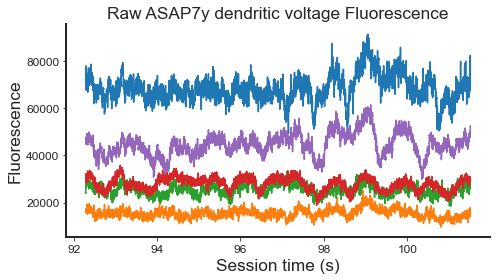

In [10]:
fig,ax=plt.subplots(figsize=(7,4))

sns.despine()

 

im_rate = 10_800
t = np.linspace((len(traces[0])/im_rate)*trial,(len(traces[0])/im_rate)*(trial+1),len(traces[0]))

for i,d in enumerate(traces[:5]):
    ax.plot(t,d)
    
ax.set_xlabel('Session time (s)')
ax.set_ylabel('Fluorescence')

ax.set_title('Raw ASAP7y dendritic voltage Fluorescence')

fig.tight_layout()
filen = 'rw_F_example'
save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)

In [11]:
session_traces = concat_rois_across_trials(vs,dmd=dmd)

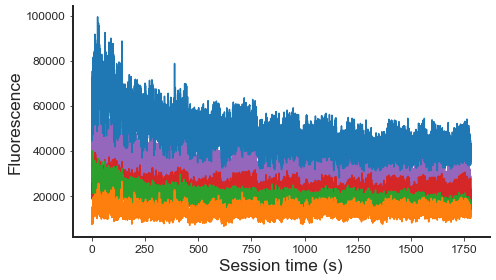

In [12]:
fig,ax=plt.subplots(figsize=(7,4))

sns.despine()

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
for spine in ['left','bottom']:
    ax.spines[spine].set_linewidth(2)

im_rate = 10_800
t = np.linspace(0,len(session_traces[0][0])/im_rate,len(session_traces[0][0]))
t_window = [0,1800]

for i,d in enumerate(session_traces[0][:5]):
    ax.plot(t[(t>t_window[0])&(t<t_window[1])][::100],d[(t>t_window[0])&(t<t_window[1])][::100],zorder=-i)
    
ax.set_xlabel('Session time (s)')
ax.set_ylabel('Fluorescence')

# ax.set_title('Raw ASAP7y dendritic voltage Fluorescence')

fig.tight_layout()
filen = 'raw_F_example_session'
save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)

### Plot comparison between F, F0, and dFF for one ROI

Inspecting: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


<IPython.core.display.Javascript object>


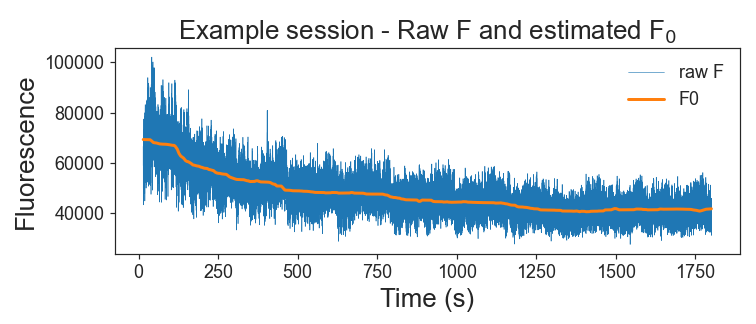

<IPython.core.display.Javascript object>


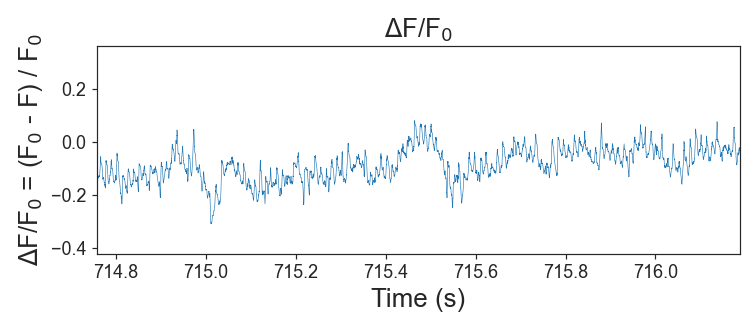

In [20]:
dmd = 1
roi_index = 0
trace_signal = "dff_robust_f0"

session_trace_h5 = asset.derived_dir / 'voltage' / 'voltage_session_traces_dff_robust_f0_trial.h5'
print("Inspecting:", session_trace_h5)

if not session_trace_h5.exists():
    print("Session trace H5 not found. Run voltage extraction first, or use the next cell to compute one ROI on the fly.")
else:
    roi = load_voltage_roi_transform_h5(session_trace_h5, dmd=dmd, roi_index=roi_index)
    t = roi["timebase_sec"]
    raw_f = roi["raw_f"]
    f0 = roi["f0"]
    dff = roi["dff"]
    window = (0,1800)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    ax.plot(t[t<=window[1]], raw_f[t<=window[1]], lw=0.4, label="raw F")
    ax.plot(t[t<=window[1]], f0[t<=window[1]], lw=2.0, label="F0")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Fluorescence")
    ax.set_title("Example session - Raw F and estimated F$_{0}$")
    ax.legend(frameon=False,fontsize=12)
    fig.tight_layout()
    filen = 'rawF_F0_example'
    save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)
    
    fig, ax = plt.subplots(figsize=(7, 3))
    ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
    ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
    ax.plot(t[t<=window[1]], dff[t<=window[1]], lw=0.4)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("\u0394F/F$_{0}$ = (F$_{0}$ - F) / F$_{0}$")
    ax.set_title('\u0394F/F$_{0}$')
    fig.tight_layout()
    filen = 'dFF_example'
    save_figure(fig,os.path.join(SAVE_PATH,filen),formats = ['.pdf','.png'],dpi=300)

### Plot whole-session raw F for all ROIs and DMDs

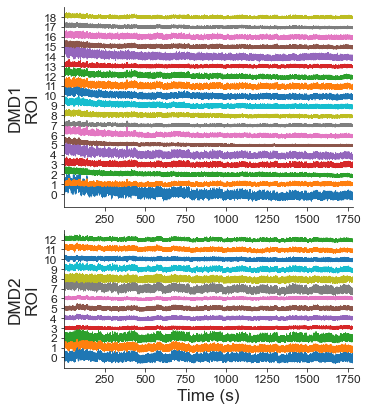

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

from vip_slap2_analysis.voltage.postprocess import concat_rois_across_trials


def _minmax_downsample_2d(X, sample_rate_hz=10_800, max_points=40_000):
    """
    X is time x ROI.
    Preserves the min/max envelope within temporal bins, much better than simple
    striding for voltage traces with brief excursions.
    """
    X = np.asarray(X)
    n_samples, n_rois = X.shape

    if n_samples <= max_points:
        return np.arange(n_samples, dtype=np.float64) / sample_rate_hz, X

    n_bins = max(1, max_points // 2)
    bin_size = max(1, n_samples // n_bins)
    n_use = (n_samples // bin_size) * bin_size

    Xb = X[:n_use].reshape(n_use // bin_size, bin_size, n_rois)

    ymin = np.nanmin(Xb, axis=1)
    ymax = np.nanmax(Xb, axis=1)

    xb = (
        np.arange(ymin.shape[0], dtype=np.float64) * bin_size
        + 0.5 * bin_size
    ) / sample_rate_hz

    x_plot = np.repeat(xb, 2)

    X_plot = np.empty((2 * ymin.shape[0], n_rois), dtype=np.float32)
    X_plot[0::2] = ymin
    X_plot[1::2] = ymax

    return x_plot, X_plot


def _robust_spacing(X_plot, overlap=0.90, min_spacing=1.0):
    """
    Data-driven vertical spacing. Smaller overlap gives more overlap;
    larger overlap gives more separation.
    """
    lo = np.nanpercentile(X_plot, 2, axis=0)
    hi = np.nanpercentile(X_plot, 98, axis=0)
    robust_ranges = hi - lo

    spacing = np.nanpercentile(robust_ranges, 90) * overlap

    if not np.isfinite(spacing) or spacing <= 0:
        spacing = min_spacing

    return max(float(spacing), float(min_spacing))


def plot_concatenated_voltage_rois(
    vs,
    *,
    dmds=(1, 2),
    sample_rate_hz=10_800,
    max_points=40_000,
    time_unit="min",        # "s" or "min"
    spacing=None,           # None = estimate separately per DMD
    overlap=0.90,
    center="median",        # "median", "mean", "first", or None
    drop_discarded=True,
    trace_mode="trial",
    dtype=np.float32,
    roi_height=0.22,        # inches per ROI
    min_axis_height=1.4,
    width=8.0,
    lw=0.45,
    rasterized=True,
):
    loaded = {}
    n_by_dmd = []

    for dmd in dmds:
        X, trial_slices = concat_rois_across_trials(
            vs,
            dmd=dmd,
            drop_discarded=drop_discarded,
            dtype=dtype,
            return_array=True,
            trace_mode=trace_mode,
        )

        # X is time x ROI.
        loaded[int(dmd)] = {
            "X": X,
            "trial_slices": trial_slices,
        }
        n_by_dmd.append(int(X.shape[1]))

    height_ratios = [max(1, n) for n in n_by_dmd]
    fig_height = sum(max(min_axis_height, roi_height * n) for n in n_by_dmd) + 0.8

    fig, axes = plt.subplots(
        len(dmds),
        1,
        figsize=(width, fig_height),
        sharex=True,
        gridspec_kw={"height_ratios": height_ratios},
        constrained_layout=True,
    )


    axes = np.atleast_1d(axes)
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", ["k"])

    for ax, dmd, n_rois in zip(axes, dmds, n_by_dmd):
        X = loaded[int(dmd)]["X"]

        x_sec, Xp = _minmax_downsample_2d(
            X,
            sample_rate_hz=sample_rate_hz,
            max_points=max_points,
        )

        if time_unit.lower().startswith("min"):
            x = x_sec / 60
            xlabel = "Time (min)"
        else:
            x = x_sec
            xlabel = "Time (s)"

        if center is None:
            centers = np.zeros(n_rois, dtype=float)
        elif center == "median":
            centers = np.nanmedian(Xp, axis=0)
        elif center == "mean":
            centers = np.nanmean(Xp, axis=0)
        elif center == "first":
            centers = np.nanmean(Xp[:min(1000, Xp.shape[0])], axis=0)
        else:
            raise ValueError("center must be 'median', 'mean', 'first', or None")

        X_centered = Xp - centers

        this_spacing = spacing
        if this_spacing is None:
            this_spacing = _robust_spacing(X_centered, overlap=overlap)

        offsets = np.arange(n_rois, dtype=float) * float(this_spacing)

        segments = []
        colors = []

        for r in range(n_rois):
            y = X_centered[:, r] + offsets[r]
            segments.append(np.column_stack((x, y)))
            colors.append(color_cycle[r % len(color_cycle)])

        lc = LineCollection(
            segments,
            colors=colors,
            linewidths=lw,
            rasterized=rasterized,
        )

        ax.add_collection(lc)
        ax.autoscale_view()
        ax.margins(x=0, y=0.03)

        ax.set_yticks(offsets)
        ax.set_yticklabels(np.arange(n_rois))
        ax.set_ylabel(f"DMD{dmd}\nROI")

        ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
        ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)
        ax.spines[["top", "right"]].set_visible(False)

    axes[-1].set_xlabel(xlabel)

    return fig, axes, loaded


fig, ax, loaded = plot_concatenated_voltage_rois(
    vs,
    dmds=(1, 2),
    sample_rate_hz=10_800,
    max_points=40_000,
    time_unit="sec",
    overlap=1,
    roi_height=0.15,
    width=5,
)

filen = "raw_example_fast_even_spacing"
save_figure(
    fig,
    os.path.join(SAVE_PATH, filen),
    formats=[".pdf", ".png"],
    dpi=300,
)

### Plot traces from several candidate ROIs at multiple timescales

In [15]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection


def _as_roi_labels(roi_ids, roi_indices):
    labels = []
    for r in roi_indices:
        if roi_ids is None:
            labels.append(str(r))
        else:
            v = roi_ids[r]
            if isinstance(v, bytes):
                v = v.decode()
            labels.append(str(v))
    return labels


def _read_dff_window_h5(
    h5_path,
    *,
    dmd,
    roi_indices,
    window_sec,
    signal="dff",
):
    """
    Reads only a time window and selected ROIs from a voltage session trace H5.

    Expected H5 structure:
        DMD1/dff or DMD2/dff
        DMD1/timebase_sec
        optionally DMD1/roi_ids

    Supports both ROI x time and time x ROI storage.
    """
    dmd_key = f"DMD{int(dmd)}"

    with h5py.File(h5_path, "r") as h5:
        g = h5[dmd_key]
        t_ds = g["timebase_sec"]
        y_ds = g[signal]

        # Reading the timebase is usually acceptable and makes windowing robust.
        t_all = t_ds[:]

        i0, i1 = np.searchsorted(t_all, window_sec)
        i0 = max(0, int(i0))
        i1 = min(len(t_all), int(i1))

        t = t_all[i0:i1]

        roi_indices = np.asarray(roi_indices, dtype=int)

        # Expected current format is ROI x time, but support time x ROI too.
        if y_ds.shape[-1] == len(t_all):
            X = y_ds[roi_indices, i0:i1].T
        elif y_ds.shape[0] == len(t_all):
            X = y_ds[i0:i1, roi_indices]
        else:
            raise ValueError(
                f"Could not infer orientation for {dmd_key}/{signal}: "
                f"shape={y_ds.shape}, timebase={len(t_all)}"
            )

        roi_ids = g["roi_ids"][:] if "roi_ids" in g else None
        labels = _as_roi_labels(roi_ids, roi_indices)

    return t, np.asarray(X, dtype=np.float32), labels


def _minmax_downsample(t, X, max_points=60_000):
    """
    Min/max envelope downsampling for time x ROI data.
    Better than striding for long voltage traces.
    """
    t = np.asarray(t)
    X = np.asarray(X)

    n_samples, n_rois = X.shape

    if max_points is None or n_samples <= max_points:
        return t, X

    n_bins = max(1, max_points // 2)
    bin_size = max(1, n_samples // n_bins)
    n_use = (n_samples // bin_size) * bin_size

    Xb = X[:n_use].reshape(n_use // bin_size, bin_size, n_rois)
    tb = t[:n_use].reshape(n_use // bin_size, bin_size)

    ymin = np.nanmin(Xb, axis=1)
    ymax = np.nanmax(Xb, axis=1)
    tmid = np.nanmean(tb, axis=1)

    t_plot = np.repeat(tmid, 2)

    X_plot = np.empty((2 * ymin.shape[0], n_rois), dtype=np.float32)
    X_plot[0::2] = ymin
    X_plot[1::2] = ymax

    return t_plot, X_plot


def _robust_spacing(X, multiplier=1.15, min_spacing=0.02):
    lo = np.nanpercentile(X, 2, axis=0)
    hi = np.nanpercentile(X, 98, axis=0)
    ranges = hi - lo

    spacing = np.nanpercentile(ranges, 90) * multiplier

    if not np.isfinite(spacing) or spacing <= 0:
        spacing = min_spacing

    return max(float(spacing), float(min_spacing))


def plot_selected_dff_rois(
    h5_path,
    *,
    dmd_rois,
    window_sec,
    signal="dff",
    max_points=60_000,
    time_unit="s",
    center="median",
    spacing=None,
    spacing_multiplier=1.15,
    lw=0.55,
    width=8,
    roi_height=0.32,
    min_height=2.2,
    title=None,
    event_spans=None,
    event_lines=None,
    save_path=None,
    save_name=None,
):
    """
    Plot selected dFF traces from both DMDs in a single stacked axis.

    Parameters
    ----------
    dmd_rois:
        Dict mapping DMD number to ROI indices.
        Example: {1: [0, 2, 5], 2: [1, 4, 9]}

    window_sec:
        Absolute session-time window in seconds.
        Example: (300, 420)

    event_spans:
        Optional list of absolute-time spans:
        [(start_sec, end_sec, label), ...]

    event_lines:
        Optional list of absolute-time vertical lines:
        [(time_sec, label), ...]
    """
    traces = []

    for dmd, roi_indices in dmd_rois.items():
        t, X, labels = _read_dff_window_h5(
            h5_path,
            dmd=dmd,
            roi_indices=roi_indices,
            window_sec=window_sec,
            signal=signal,
        )

        for j, roi_label in enumerate(labels):
            traces.append(
                {
                    "dmd": int(dmd),
                    "roi_index": int(roi_indices[j]),
                    "roi_label": roi_label,
                    "t": t,
                    "y": X[:, j],
                }
            )

    n_traces = len(traces)
    fig_height = max(min_height, roi_height * n_traces + 1.0)

    fig, ax = plt.subplots(figsize=(width, fig_height))

    # Use one shared timebase after downsampling each trace.
    segments = []
    ytick_pos = []
    ytick_labels = []

    color_cycle = ['#e99c81','#7bbcd5']

    # Estimate spacing from all selected traces after downsampling.
    downsampled = []
    for tr in traces:
        tp, yp = _minmax_downsample(
            tr["t"],
            tr["y"][:, None],
            max_points=max_points,
        )

        y = yp[:, 0]

        if center == "median":
            y = y - np.nanmedian(y)
        elif center == "mean":
            y = y - np.nanmean(y)
        elif center == "first":
            y = y - np.nanmean(y[:min(1000, len(y))])
        elif center is None:
            pass
        else:
            raise ValueError("center must be 'median', 'mean', 'first', or None")

        downsampled.append((tp, y))

    if spacing is None:
        spacing = _robust_spacing(
            np.column_stack([y for _, y in downsampled]),
            multiplier=spacing_multiplier,
        )

    for k, (tr, (tp, y)) in enumerate(zip(traces, downsampled)):
        offset = k * spacing

        if time_unit.lower().startswith("min"):
            x = (tp - window_sec[0]) / 60
            xlabel = f"Time (min)"
        else:
            x = tp - window_sec[0]
            xlabel = f"Time (s)"

        segments.append(np.column_stack([x, y - offset]))
        ytick_pos.append(-offset)
        ytick_labels.append(f"{tr['roi_index']}")

    colors = [
        color_cycle[(tr["dmd"] - 1) % len(color_cycle)]
        for tr in traces
    ]

    for seg, color in zip(segments, colors):
        ax.plot(
            seg[:, 0],
            seg[:, 1],
            color=color,
            lw=lw,
            rasterized=False,
            solid_joinstyle="round",
            solid_capstyle="round",
        )

    ax.relim()
    ax.autoscale_view()
    ax.margins(x=0, y=0.04)

    # Optional absolute-time event spans.
    if event_spans is not None:
        for start, end, label in event_spans:
            if end < window_sec[0] or start > window_sec[1]:
                continue

            if time_unit.lower().startswith("min"):
                xs = (start - window_sec[0]) / 60
                xe = (end - window_sec[0]) / 60
            else:
                xs = start - window_sec[0]
                xe = end - window_sec[0]

            ax.axvspan(xs, xe, alpha=0.14, lw=0)

    # Optional absolute-time event lines.
    if event_lines is not None:
        for t_event, label in event_lines:
            if t_event < window_sec[0] or t_event > window_sec[1]:
                continue

            if time_unit.lower().startswith("min"):
                x_event = (t_event - window_sec[0]) / 60
            else:
                x_event = t_event - window_sec[0]

            ax.axvline(x_event, ls="--", lw=0.8, alpha=0.55)

    ax.set_yticks(ytick_pos)
    ax.set_yticklabels(ytick_labels)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Selected ROIs")
    ax.set_title(title or f"{signal} traces, {window_sec[0]:.1f}–{window_sec[1]:.1f} s")

    ax.tick_params(axis="x", which="major", reset=True, top=False, labelsize=12)
    ax.tick_params(axis="y", which="major", reset=True, right=False, labelsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    # Small amplitude scale bar in dFF units.
    scale = spacing / 2
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    xb = x1 - 0.04 * (x1 - x0)
    yb = y0 + 0.08 * (y1 - y0)
    ax.plot([xb, xb], [yb, yb + scale], lw=1.5, color="k", clip_on=False)
    ax.text(
        xb,
        yb + scale / 2,
        f"{scale:.3g} dFF",
        va="center",
        ha="left",
        fontsize=9,
    )

    fig.tight_layout()

    if save_path is not None and save_name is not None:
        save_figure(
            fig,
            os.path.join(save_path, save_name),
            formats=[".pdf", ".png"],
            dpi=300,
        )

    return fig, ax, traces

In [16]:
n_rois = vs.n_rois
n_rois

[19, 13]

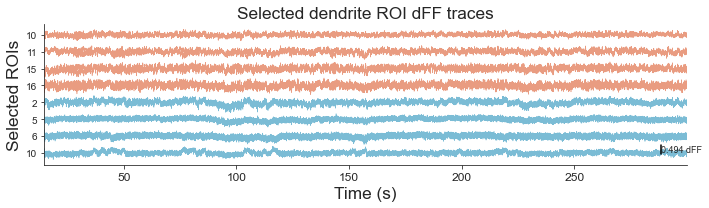

In [17]:
RAND_ROI = False

session_trace_h5 = (
    asset.derived_dir
    / "voltage"
    / "voltage_session_traces_dff_robust_f0_trial.h5"
)

roi_idx = [[10,11,15,16],
           [2,5,6,10]] #specific ROI ids by DMD
num_rois = 4

if RAND_ROI:
    dmd_rois = {
        1: np.sort(np.random.randint(0,len(range(n_rois[0])),num_rois)),
        2: np.sort(np.random.randint(0,len(range(n_rois[1])),num_rois)),
    }
else:
    if roi_idx is not None:
        dmd_rois = {
            1: np.arange(0,n_rois[0])[roi_idx[0]],
            2: np.arange(0,n_rois[1])[roi_idx[1]]
        }
    else:
        dmd_rois = {
            1: np.arange(0,n_rois[0])[:num_rois],
            2: np.arange(0,n_rois[1])[:num_rois]
        }
fig, ax, traces = plot_selected_dff_rois(
    session_trace_h5,
    dmd_rois=dmd_rois,
    window_sec=(0, 300),      # absolute session time in seconds
    signal="dff",
    max_points=80_000,
    time_unit="s",
    spacing_multiplier=2,
    width=10,
    roi_height=0.25,
    title="Selected dendrite ROI dFF traces",
    save_path=SAVE_PATH,
    save_name="selected_dff_rois",
)

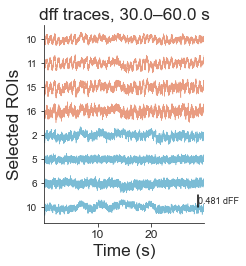

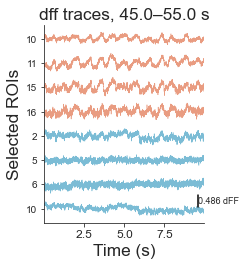

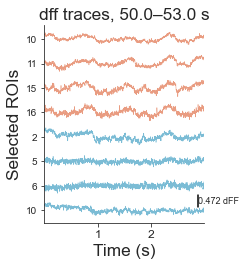

In [18]:
windows = {
    "long": (30, 60),
    "medium": (45, 55),
    "short": (50,53),
}

for label, window_sec in windows.items():
    fig, ax, _ = plot_selected_dff_rois(
        session_trace_h5,
        dmd_rois=dmd_rois,
        window_sec=window_sec,
        signal="dff",
        max_points=80_000,
        time_unit="s" if (window_sec[1] - window_sec[0]) <= 180 else "min",
        spacing_multiplier=2,
        width=3.5,
        roi_height=0.35,
        title=None,
        save_path=SAVE_PATH,
        save_name=f"selected_dff_rois_{label}",
    )